# Photodiode readout noise in gwinc

Cell overview:

1. imports and plot style
2. the `PDReadoutNoise` model
3. device / front-end parameter database
4. A+ budget with the photodiode term
5. `QESweep`
6. volume loss per detector


## 1. Imports, style, globals

In [1]:

import copy, os
import numpy as np
import scipy.constants as sc
import gwinc
from gwinc import nb, Struct
from gwinc.noise.quantum import precomp_quantum, Readout as ReadoutVacuum
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})

try:
    import inspiral_range, logging
    logging.getLogger('inspiral_range').setLevel(logging.ERROR)
    HAVE_IR = True
except ModuleNotFoundError:
    HAVE_IR = False
    print('inspiral_range missing: pip install inspiral-range  (falling back to proxy)')

_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

path    = "/Users/asca/PhD/photodiodes/code/gwinc/"
fig_dir = os.path.join(path, "fig")
os.makedirs(fig_dir, exist_ok=True)

#  house style, shared by every figure below
PD_KEY = 'PDReadoutNoise'
noise_style = {
    'Quantum':                dict(label=r'Quantum noise',              color='#1f3864', ls='-',  lw=3.6),
    'Seismic':                dict(label=r'Seismic noise',              color='#2ca9a3', ls='-',  lw=1.6),
    'Newtonian':              dict(label=r'Gravity-gradient noise',     color='#2ca9a3', ls=':',  lw=1.8),
    'SuspensionThermal':      dict(label=r'Suspension thermal noise',   color='#c0392b', ls='-',  lw=1.6),
    'CoatingBrownian':        dict(label=r'Coating Brownian noise',     color='#c0392b', ls=':',  lw=1.8),
    'CoatingThermoOptic':     dict(label=r'Coating thermo-refractive',  color='#e8a33d', ls='-',  lw=1.6),
    'SubstrateBrownian':      dict(label=r'Substrate Brownian noise',   color='#e8a33d', ls=':',  lw=1.8),
    'SubstrateThermoElastic': dict(label=r'Substrate thermo-elastic',   color='#af7ac5', ls=':',  lw=1.8),
    'ITMThermoRefractive':    dict(label=r'ITM thermo-refractive',      color='#af7ac5', ls='-',  lw=1.6),
    'ResidualGas':            dict(label=r'Residual gas',               color='#555555', ls='-.', lw=1.4),
    'ExcessGas':              dict(label=r'Residual gas',               color='#555555', ls='-.', lw=1.4),
    PD_KEY:                   dict(label=r'PD dark current $+$ electronics',
                                   color='#6a3d9a', ls='-',  lw=4.0),
}

def texsafe(s):
    """Escape a raw gwinc key so usetex does not choke on it."""
    return s.replace('_', r'\_').replace('%', r'\%').replace('&', r'\&')

Using 'astropy' for cosmological calculations.  Install the 'lal' package for better performance.


## 2. The model

$$\rho(f)=\frac{N\,S_i(f)}{2eI_{\rm dc}}=\frac{S_i(f)}{2eI_{\rm pd}},
\qquad S_h^{\rm PD}(f)=\rho(f)\,S_h^{\rm shot}(f)$$

Balanced homodyne **subtracts** the two photocurrents, DC readout **sums** two
DCPDs. Either way the signal combines coherently and the dark sides do not, so
$N$ cancels and $\rho$ depends only on the per-diode photocurrent.

In [2]:

class PDReadoutNoise(nb.Noise):
    """Photodiode dark current + readout electronics, referred to strain.

    Dark-side and shot noise are both current noises injected at the
    photodiode, so they share the optical-to-strain transfer function and
    their current-PSD ratio rho transfers directly.  The shot reference is
    gwinc's own readout-loss vacuum term, Quantum.Readout / (1 - eta).

    N diodes.  BHD subtracts, DC readout sums; either way the signal combines
    coherently and the dark sides do not, so rho = S_i / (2 e I_pd) and the N
    cancels.  Returns DISPLACEMENT psd.
    """
    style = dict(label=r'PD dark + electronics', color='#6a3d9a', linestyle='-')

    @nb.precomp(quantum=precomp_quantum)
    def calc(self, quantum):
        ifo, f = self.ifo, self.freq
        pd, eta = ifo.Optics.Readout, ifo.Optics.PhotoDetectorEfficiency

        # photocurrent
        R = (pd.Responsivity if 'Responsivity' in pd
             else eta * sc.e * ifo.Laser.Wavelength / (sc.h * sc.c))
        I_dc = pd.Photocurrent if 'Photocurrent' in pd else R * pd.LOPower
        N    = pd.get('NDiodes', 2)

        # dark-side current-noise PSD per diode [A^2/Hz]
        I_dk = pd.get('DarkCurrent', 0.0)
        T    = pd.get('Temperature', 298.0)

        S_shot_dark = 2 * sc.e * I_dk
        S_johnson   = 4 * sc.k * T / pd.Rshunt if pd.get('Rshunt') else 0.0

        # electronics: prefer NoiseEquivalentPhotocurrent, else CurrentNoise
        if 'NoiseEquivalentPhotocurrent' in pd:
            i_n2 = 2 * sc.e * pd.NoiseEquivalentPhotocurrent
        else:
            i_n2 = pd.get('CurrentNoise', 0.0) ** 2

        # optional 1/f amplifier noise
        fc = pd.get('AmpCorner', 0.0)
        be = pd.get('AmpExponent', 1.0)
        S_amp = i_n2 * (1 + (fc / f)**be if fc else 1.0)

        # optional Hooge / flicker (classic form)
        aH = pd.get('HoogeAlpha', 0.0)
        bH = pd.get('HoogeExponent', 2.0)
        I_pd = I_dc / N
        S_hooge = aH * (I_pd + I_dk)**bH / f if aH else 0.0

        S_i = S_shot_dark + S_johnson + S_amp + S_hooge
        rho = N * S_i / (2 * sc.e * I_dc)

        self.rho   = float(rho) if np.isscalar(rho) else float(rho[np.argmin(np.abs(f - 1000))])
        self.rho_f = rho if not np.isscalar(rho) else rho * np.ones_like(f)
        self.S_i   = S_i * np.ones_like(f)

        # convert to strain using the ordinary shot-noise reference
        lam = 1 - eta
        if lam >= 1e-4:
            shot = quantum.PD / lam
        else:
            p = copy.deepcopy(ifo)
            lam = 1e-3
            p.Optics.PhotoDetectorEfficiency = 1 - lam
            shot = ReadoutVacuum(freq=f, ifo=p)._calc(dict()) / lam

        return self.rho_f * shot


def budget_with_pd(name, freq, eta, **pd):
    """Return a budget that includes PDReadoutNoise."""
    b0 = gwinc.load_budget(name, freq=freq)
    b0.ifo.Optics.PhotoDetectorEfficiency = float(eta)
    b0.ifo.Optics.Readout = Struct(**pd)
    cls = type(name + 'PD', (type(b0),),
               dict(noises=list(type(b0).noises) + [PDReadoutNoise]))
    return cls(freq=freq, ifo=b0.ifo)

## 3. Parameter database

`None` means **not measured** and is reported, never silently zeroed.

In [3]:

eta_ext = lambda R, f_dead, eta_int: (1 - R)*(1 - f_dead)*eta_int

# ---- FRONT-END (circuit).  Grote et al. 2016, Opt. Express 24, 20107 ----
FRONTEND = {
 'Grote2016': dict(
    NoiseEquivalentPhotocurrent = 5e-6,    # A   -- quoted in the paper, ABOVE 1 kHz
    AmpCorner                   = None,    # Hz  -- MEASURE (LISO / dark spectrum)
    AmpExponent                 = 0.5,     # ASD exponent
    UsableCurrent               = 20e-3),  # A   -- circuit's usable range
 'Grote2016_50mA': dict(
    # SAME circuit noise, usable range raised to the LIGO operating current.
    # ASSUMPTION, not a published number -- see the alog entries.
    NoiseEquivalentPhotocurrent = 5e-6,
    AmpCorner                   = None,
    AmpExponent                 = 0.5,
    UsableCurrent               = 50e-3),
 'Generic_TIA': dict(
    CurrentNoise = 3e-12, AmpCorner = 100.0, AmpExponent = 0.5, UsableCurrent = 10e-3),
}
I_N_GROTE = np.sqrt(2*sc.e*FRONTEND['Grote2016']['NoiseEquivalentPhotocurrent'])  # 1.27 pA/rtHz

# ---- DEVICE (per diode).  None = not measured; readout_block will say so ----
DEVICE = {
 'IGHQEX0500': dict(
    DarkCurrent=800e-12, Rshunt=None, Temperature=298.0, MaxCurrent=10e-3,
    FlickerA=None, FlickerBeta=0.5, FlickerRefCurrent=None, FlickerCurrentExponent=2.0),
 'LIGO_DCPD': dict(
    # aLIGO / A+ OMC photodiodes: a dedicated ~2006 production run, NOT a
    # catalogue part.  Dark current unmeasured; MaxCurrent inferred from the
    # reported ~50 mA total over two diodes.
    DarkCurrent=None, Rshunt=None, Temperature=298.0, MaxCurrent=25e-3,
    FlickerA=None, FlickerBeta=0.5, FlickerRefCurrent=None, FlickerCurrentExponent=2.0),
 'eInGaAs_2um': dict(
    DarkCurrent=None, Rshunt=None, Temperature=298.0, MaxCurrent=None,
    FlickerA=None, FlickerBeta=0.5, FlickerRefCurrent=None, FlickerCurrentExponent=2.0),
 'HgCdTe_2um': dict(
    DarkCurrent=None, Rshunt=None, Temperature=298.0, MaxCurrent=None,
    FlickerA=None, FlickerBeta=0.5, FlickerRefCurrent=None, FlickerCurrentExponent=2.0),
}

def readout_block(device, frontend, I_dc_total, N=2, quiet=False):
    """Merge a DEVICE and a FRONTEND entry. Missing values are reported, never zeroed silently."""
    d, fe = DEVICE[device], FRONTEND[frontend]
    missing = []

    caps = [(fe['UsableCurrent'], 'circuit')]
    if d['MaxCurrent'] is None: missing.append('MaxCurrent (diode)')
    else:                       caps.append((N*d['MaxCurrent'], f'{N} x diode'))
    I_cap, who = min(caps)
    if I_dc_total > I_cap:
        print(f'WARNING: {I_dc_total*1e3:.1f} mA total exceeds the binding limit '
              f'{I_cap*1e3:.1f} mA ({who})')
    elif I_dc_total == I_cap and not quiet:
        print(f'NOTE: {I_dc_total*1e3:.1f} mA sits exactly on the {who} limit -- no margin')

    blk = dict(Photocurrent=I_dc_total, NDiodes=N, Temperature=d['Temperature'])
    if d['DarkCurrent'] is None: missing.append('DarkCurrent')
    else:                        blk['DarkCurrent'] = d['DarkCurrent']
    if d['Rshunt'] is None:      missing.append('Rshunt')
    else:                        blk['Rshunt'] = d['Rshunt']
    if d['FlickerA'] is None or d['FlickerRefCurrent'] is None:
        missing.append('Flicker (A and/or RefCurrent)')
    else:
        blk.update(FlickerA=d['FlickerA'], FlickerBeta=d['FlickerBeta'],
                   FlickerRefCurrent=d['FlickerRefCurrent'],
                   FlickerCurrentExponent=d['FlickerCurrentExponent'])
    for k, v in fe.items():
        if k == 'UsableCurrent': continue
        if v is None: missing.append(f'{k} (front-end)')
        else:         blk[k] = v

    if missing and not quiet:
        print(f'[{device} + {frontend}] modelled as ZERO (not measured): ' + ', '.join(missing))
    return blk

# ---- QE state of the art (May 2026 review, Table 2) ----
QE_SOTA = {
    ('LM InGaAs', 1064): (0.99, 0.995),  ('LM InGaAs', 1550): (0.80, 0.995),
    ('eInGaAs',   1064): (0.90, 0.90),   ('eInGaAs',   1550): (0.84, 0.84),
    ('eInGaAs',   2000): (0.70, 0.92),
    ('HgCdTe',    1064): (0.70, 0.80),   ('HgCdTe',    1550): (0.70, 0.80),
    ('HgCdTe',    2000): (0.70, 0.80),
}
DETECTOR_FOR_LAMBDA = {1064: 'Aplus', 2000: 'Voyager'}   # 1550: no gwinc budget

## 4. A+ budget with the photodiode term

Only the first two terms of $S_i$ are populated, so this is a **white floor** —
a lower bound on the dark-side noise.

$$S_i = \underbrace{2eI_{\rm dark}}_{\rm dark\ shot}+\underbrace{2eI_{\rm eq}}_{\rm front\ end}
\quad\Longrightarrow\quad \rho=\frac{I_{\rm dark}+I_{\rm eq}}{I_{\rm pd}}$$

I_pd        = 25.0 mA per diode
S_i         = 1.6214e-24 A^2/Hz  =  1.2733 pA/rtHz
shot ref    = 126.58 pA/rtHz
rho(1 kHz)  = 2.0240e-04   (36.94 dB below shot)
sqrt(rho)   = 1.42 %
SNR         = 70.3
S_loss      = 0.0101 %
V_loss      = 0.0304 %   (shot-limited)
I_dark share of S_i = 1.186 %


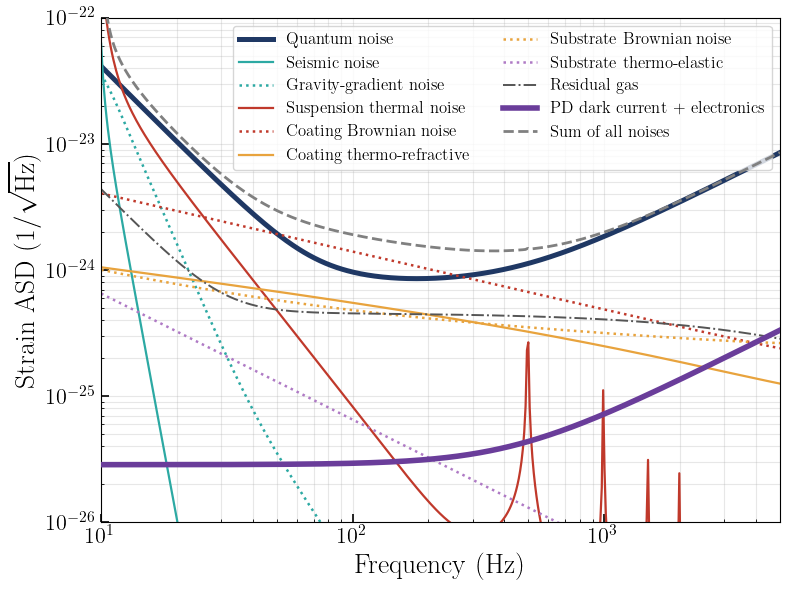

unstyled keys: none


In [4]:

# ---------------------------------------------------------------------------
#  I_DC: 50 mA total is the figure quoted for CURRENT LIGO (DC readout, two
#  summed DCPDs).  Whether A+ BHD runs the same total is NOT verified -- check
#  the alog entries.  Set to 20e-3 for the catalogue IGHQEX0500 operating point.
#
#  NOTE 25 mA per diode exceeds the 10 mA maximum on the Laser Components HQE
#  datasheet.  LIGO's devices are from a dedicated 2006 run, not catalogue
#  parts, so the 800 pA below is a stand-in for an unmeasured number.
# ---------------------------------------------------------------------------
I_EQ_GROTE = 5e-6          # A   noise-equivalent photocurrent (Grote 2016, >1 kHz)
I_DARK     = 60e-9       # A   IGHQEX0500 datasheet, at -2.5 V
I_DC       = 50e-3         # A   total photocurrent
N_DIODES   = 2
ETA        = 0.995         # gwinc: the WHOLE readout chain, not just the diode

freq_ap = np.logspace(np.log10(10), np.log10(5000), 500)

b = budget_with_pd(
    'Aplus', freq_ap, ETA,
    Photocurrent                = I_DC,
    NDiodes                     = N_DIODES,
    NoiseEquivalentPhotocurrent = I_EQ_GROTE,
    DarkCurrent                 = I_DARK,
    # AmpCorner  = 0.0,     # leave out for a pure white floor
    # HoogeAlpha = 0.0,
)

t   = b.run()
obj = b._noise_objs['PDReadoutNoise']

S_i  = 2 * sc.e * (I_DARK + I_EQ_GROTE)
I_pd = I_DC / N_DIODES
print(f'I_pd        = {I_pd*1e3:.1f} mA per diode')
print(f'S_i         = {S_i:.4e} A^2/Hz  =  {np.sqrt(S_i)*1e12:.4f} pA/rtHz')
print(f'shot ref    = {np.sqrt(2*sc.e*I_DC)*1e12:.2f} pA/rtHz')
print(f'rho(1 kHz)  = {obj.rho:.4e}   ({-10*np.log10(obj.rho):.2f} dB below shot)')
print(f'sqrt(rho)   = {100*np.sqrt(obj.rho):.2f} %')
print(f'SNR         = {1/np.sqrt(obj.rho):.1f}')
print(f'S_loss      = {100*((1+obj.rho)**0.5 - 1):.4f} %')
print(f'V_loss      = {100*((1+obj.rho)**1.5 - 1):.4f} %   (shot-limited)')
print(f'I_dark share of S_i = {100*I_DARK/(I_DARK+I_EQ_GROTE):.3f} %')

fig, ax = plt.subplots(figsize=(8, 6))

keys     = list(t.keys())
ordered  = [k for k in noise_style if k in keys and k != PD_KEY]
ordered += [k for k in keys if k not in noise_style and k != PD_KEY]

for k in ordered:
    s = noise_style.get(k, dict(label=texsafe(k), color='0.3', ls='-', lw=1.2))
    ax.loglog(freq_ap, t[k].asd, label=s['label'], color=s['color'],
              ls=s['ls'], lw=s['lw'], zorder=2)

if PD_KEY in keys:                                   # thick, on top
    s = noise_style[PD_KEY]
    ax.loglog(freq_ap, t[PD_KEY].asd, label=s['label'], color=s['color'],
              ls=s['ls'], lw=s['lw'], zorder=5)

ax.loglog(freq_ap, t.asd, label=r'Sum of all noises', color='gray',
          ls='--', lw=2.0, zorder=6)

ax.set_xlabel(r'Frequency (Hz)', fontsize=20)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=20)
ax.set_xlim(10, 5000)
ax.set_ylim(1e-26, 1e-22)
ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=1.2, direction='in')
ax.tick_params(axis='both', which='minor', direction='in')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper right', fontsize=12, frameon=True, ncol=2)

fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'Aplus_with_PD_readout_noise.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
#fig.savefig(os.path.join(fig_dir, 'Aplus_with_PD_readout_noise.svg'), bbox_inches='tight', facecolor='white')
plt.show()

print('unstyled keys:', [k for k in keys if k not in noise_style] or 'none')

## 5. QE sweep

$$S_h(\eta,\rho)=S_Q(\eta)+S_{\rm CL}+\rho\,S_{\rm shot}(\eta),
\qquad S_{\rm shot}=\frac{S_h^{\rm Quantum.Readout}}{1-\eta}$$

Sweep $\eta$ once, interpolate $\log S$, then any $(\eta,\rho)$ is free.
`extrapolate=False` plus an explicit range check, so asking outside the grid
raises instead of silently returning a cubic extrapolation.

In [5]:

#  QE deficit <-> equivalent dark-side rho <-> Grote SNR
rho_from_eta = lambda eta: (1 - eta)/eta
snr_from_eta = lambda eta: np.sqrt(eta/(1 - eta))
eta_from_snr = lambda snr: snr**2/(1 + snr**2)

ETAS_DEFAULT = np.sort(np.array([0.98, 0.99, 0.995, 0.997, 0.999, 0.9995]))


class QESweep:
    """Sweep photodiode efficiency once; evaluate any metric analytically after."""

    def __init__(self, name, freq, etas=None):
        self.name, self.freq = name, freq
        etas = ETAS_DEFAULT if etas is None else np.sort(np.asarray(etas, dtype=float))
        Q, S, CL = [], [], None
        for eta in etas:
            bq = gwinc.load_budget(name, freq=freq)
            bq.ifo.Optics.PhotoDetectorEfficiency = float(eta)
            tq = bq.run(ifo=bq.ifo)
            if CL is None:                       # eta-independent: compute once
                CL = sum(tq[k].psd for k in tq.keys() if k != 'Quantum')
            Q.append(tq['Quantum'].psd)
            S.append(tq['Quantum']['Readout'].psd/(1 - eta))
        self.etas, self.CL = etas, CL
        self.iQ = PchipInterpolator(etas, np.log(np.array(Q)), axis=0, extrapolate=False)
        self.iS = PchipInterpolator(etas, np.log(np.array(S)), axis=0, extrapolate=False)
        self.eta0 = float(etas[-1])

    def psd(self, eta=None, rho=0.0):
        eta = self.eta0 if eta is None else float(eta)
        if not (self.etas[0] <= eta <= self.etas[-1]):
            raise ValueError(
                f'{self.name}: eta={eta:.6f} is outside the sweep grid '
                f'[{self.etas[0]:.4f}, {self.etas[-1]:.4f}]. Pass a wider '
                f'etas= grid -- do not extrapolate.')
        return np.exp(self.iQ(eta)) + self.CL + rho*np.exp(self.iS(eta))

    def range_(self, eta=None, rho=0.0, m1=1.4, m2=1.4):
        p = self.psd(eta, rho)
        if HAVE_IR:
            return inspiral_range.all_ranges(self.freq, p, m1=m1, m2=m2)[0]['sensemon_range'][0]
        k = (self.freq >= 10) & (self.freq <= 1570)
        return np.sqrt(_trapz(self.freq[k]**(-7/3)/p[k], self.freq[k]))

    def hf(self, eta=None, rho=0.0, band=(1000, 4000)):
        p = self.psd(eta, rho); k = (self.freq >= band[0]) & (self.freq <= band[1])
        return 1/np.sqrt(np.mean(p[k]))

    def S_loss(self, rho):
        return self.range_(rho=0.0)/self.range_(rho=rho) - 1

    def V_loss(self, rho):
        return (self.range_(rho=0.0)/self.range_(rho=rho))**3 - 1

## 6. Volume loss per detector

$$V_{\rm loss}(\rho)=\left[\frac{r(0)}{r(\rho)}\right]^{3}-1
\;\simeq\;\left(1+\rho\,\bar\chi\right)^{3/2}-1$$

$\bar\chi$ is the range-weighted shot fraction. It is printed below, recovered
by inverting the expression, so the shot-limited reference curve does not need
to be on the figure.

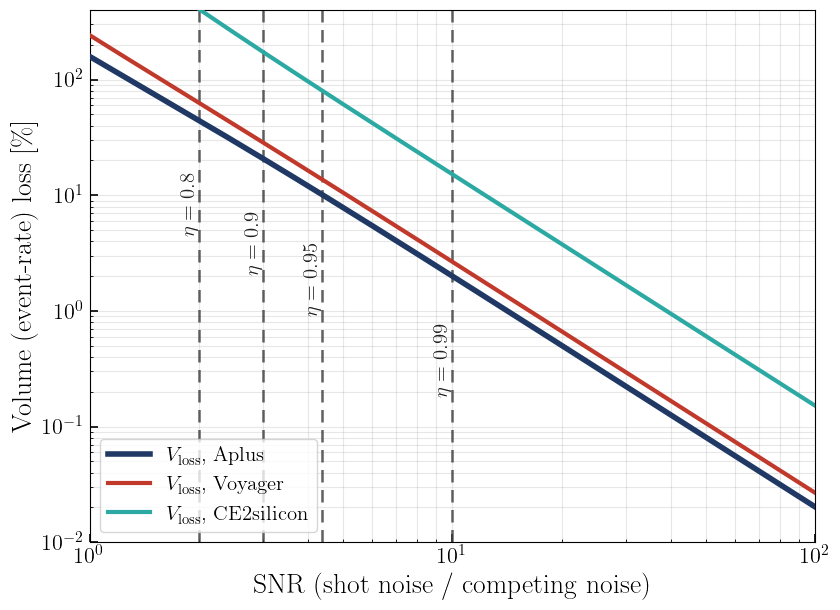

detector           sqz  r0[Mpc]  chi_bar           eta=0.80           eta=0.90           eta=0.95           eta=0.99
                                              V_loss / kept      V_loss / kept      V_loss / kept      V_loss / kept
Aplus         12 dB FD    384.1     1.30       44.5% / 69.2%       20.9% / 82.7%       10.2% / 90.7%        2.0% / 98.0%
Voyager       10 dB FD    866.6     1.73       63.2% / 61.3%       28.8% / 77.7%       13.8% / 87.9%        2.7% / 97.4%
CE2silicon    15 dB FD   8389.9     9.49      408.9% / 19.7%      174.4% / 36.4%       81.0% / 55.2%       15.3% / 86.7%

V_loss = V(0)/V(rho) - 1     kept = 1/(1 + V_loss)

step         (1-eta) reduced by           Aplus         Voyager      CE2silicon
0.8 -> 0.9               2.0x    44.5-> 20.9%    63.2-> 28.8%   408.9->174.4%
0.9 -> 0.99              10.0x    20.9->  2.0%    28.8->  2.7%   174.4-> 15.3%

\begin{table}[H]
\centering
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.3}
\begin{tabular}

In [12]:
freq = np.logspace(np.log10(5), np.log10(5000), 600)

DETS = {'aLIGO':      '#888888',   # no squeezer        (swept, not plotted)
        'Aplus':      '#1f3864',   # 12 dB FD
        'Voyager':    '#c0392b',   # 10 dB FD
        'CE2silicon': '#2ca9a3'}   # 15 dB FD

SQZ = {'aLIGO': 'none', 'Aplus': r'12\,dB FD',
       'Voyager': r'10\,dB FD', 'CE2silicon': r'15\,dB FD'}

PLOT_ORDER = ['Aplus', 'Voyager', 'CE2silicon']
LW = {'Aplus': 4.0, 'Voyager': 3.0, 'CE2silicon': 3.0}

#  A photodiode of efficiency eta transmits eta of the signal-bearing light
#  and admits (1-eta) of fresh unsqueezed vacuum.  Measuring the noise it
#  ADDED against the shot noise that SURVIVED -- both attenuated by the same
#  factor, so the transfer cancels:
#      rho = (1-eta)/eta        SNR = 1/sqrt(rho) = sqrt(eta/(1-eta))
QE_MARKS = [0.80, 0.90, 0.95, 0.99]

YLIM = (1e-2, 4e2)
LABEL_DROP = 0.16      # how far below the lowest curve the label sits
LABEL_FLOOR = 0.30     # never go below this, to clear the legend

sw = {n: QESweep(n, freq) for n in DETS}

snr = np.logspace(0, 2, 160)
rho = 1/snr**2

fig, ax = plt.subplots(figsize=(8.5, 6.2))

for n in PLOT_ORDER:
    ax.loglog(snr, [100*sw[n].V_loss(r) for r in rho],
              lw=LW[n], color=DETS[n], zorder=3,
              label=rf'$V_{{\rm loss}}$, {n}')

# --- QE mapped onto the same axis ------------------------------------------
def _yfrac(v):
    """percent value -> axis fraction on the log y-axis"""
    lo, hi = np.log10(YLIM[0]), np.log10(YLIM[1])
    return (np.log10(v) - lo)/(hi - lo)

for eta in QE_MARKS:
    x = snr_from_eta(eta)
    ax.axvline(x, color='#444444', lw=1.8, ls=(0, (5, 3)), zorder=2, alpha=0.85)

    #  drop the label into the gap: below the lowest curve, above the legend
    y_low = min(_yfrac(100*sw[n].V_loss((1 - eta)/eta)) for n in PLOT_ORDER)
    y = max(y_low - LABEL_DROP, LABEL_FLOOR)
    ax.text(x, y, rf'$\eta={eta}$', rotation=90, fontsize=15,
            va='center', ha='right', color='#222222',
            transform=ax.get_xaxis_transform(), zorder=7)

ax.set_xlabel(r'SNR  (shot noise / competing noise)', fontsize=20)
ax.set_ylabel(r'Volume (event-rate) loss [\%]', fontsize=20)
ax.set_xlim(1, 100)
ax.set_ylim(*YLIM)
ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=1.2,
               direction='in')
ax.tick_params(axis='both', which='minor', direction='in')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='lower left', fontsize=15, frameon=True)

fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'volume_loss_per_detector.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
#fig.savefig(os.path.join(fig_dir, 'volume_loss_per_detector.svg'), bbox_inches='tight', facecolor='white')
plt.show()


# ---------------------------------------------------------------------------
#  chi_bar, recovered by inverting  V_loss = (1 + rho*chi_bar)^{3/2} - 1
# ---------------------------------------------------------------------------
def chi_bar(name, probes=(1/16, 0.01)):
    vals = [((1 + sw[name].V_loss(r))**(2/3) - 1)/r for r in probes]
    return float(np.mean(vals)), float(np.ptp(vals))


CHI = {n: chi_bar(n) for n in DETS}

# ---------------------------------------------------------------------------
#  V_loss = V(0)/V(rho) - 1 is an INFLATION factor, not a fraction lost.
#  V_loss = 100 % means the volume HALVED; events kept = 1/(1 + V_loss).
# ---------------------------------------------------------------------------
print(f'{"detector":12s}{"sqz":>10s}{"r0[Mpc]":>9s}{"chi_bar":>9s}'
      + ''.join(f'{"eta=" + f"{e:.2f}":>19s}' for e in QE_MARKS))
print(f'{"":40s}' + ''.join(f'{"V_loss / kept":>19s}' for _ in QE_MARKS))
for n in PLOT_ORDER:
    c, _ = CHI[n]
    row = (f'{n:12s}{SQZ[n].replace(chr(92) + ",", " "):>10s}'
           f'{sw[n].range_():9.1f}{c:9.2f}')
    for e in QE_MARKS:
        v = sw[n].V_loss((1 - e)/e)
        row += f'{100*v:11.1f}% /{100/(1 + v):5.1f}%'
    print(row)
print('\nV_loss = V(0)/V(rho) - 1     kept = 1/(1 + V_loss)')

# --- why 0.90 -> 0.99 is worth more than 0.80 -> 0.90 ----------------------
print('\nstep         (1-eta) reduced by' + ''.join(f'{n:>16s}' for n in PLOT_ORDER))
for a, b in ((0.80, 0.90), (0.90, 0.99)):
    row = f'{a} -> {b}{(1-a)/(1-b):18.1f}x'
    for n in PLOT_ORDER:
        va, vb = (sw[n].V_loss((1-e)/e) for e in (a, b))
        row += f'{100*va:8.1f}->{100*vb:5.1f}%'
    print(row)


# ---------------------------------------------------------------------------
#  Emit the LaTeX table so the slide numbers cannot drift from the code.
# ---------------------------------------------------------------------------
def emit_chi_table(dets=PLOT_ORDER):
    print(r'\begin{table}[H]')
    print(r'\centering')
    print(r'\small')
    print(r'\setlength{\tabcolsep}{5pt}')
    print(r'\renewcommand{\arraystretch}{1.3}')
    print(r'\begin{tabular}{>{\raggedright\arraybackslash}m{3.2cm}'
          r'                >{\centering\arraybackslash}m{2.6cm}'
          r'                >{\centering\arraybackslash}m{2.4cm}}')
    print(r'\toprule')
    print(r'\textbf{Detector} & \textbf{Squeezing} & $\bar\chi$ \\')
    print(r'\midrule')
    for n in dets:
        c, _ = CHI[n]
        nm = n.replace('CE2silicon', 'CE2 silicon').replace('Aplus', 'A+')
        print(rf'{nm} & {SQZ[n]} & ${c:.2f}$ \\')
    print(r'\bottomrule')
    print(r'\end{tabular}')
    print(r'\end{table}')


print()
emit_chi_table()